In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data Explotation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #Visualization
import seaborn as sns #Advanced Visualization
%matplotlib inline

# Data modelling libraries
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score

In [2]:
#Loading data 
fraud = pd.read_csv("Fraud Detection Dataset.csv")
fraud.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [3]:
fraud.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [4]:
#drop columns Transaction_ID
fraud = fraud.drop(columns=['Transaction_ID', 'User_ID'])

In [5]:
# view the numeric col 
numeric_col = fraud.select_dtypes(include=['int64', 'float64']).columns
print(numeric_col)

Index(['Transaction_Amount', 'Time_of_Transaction',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Fraudulent'],
      dtype='object')


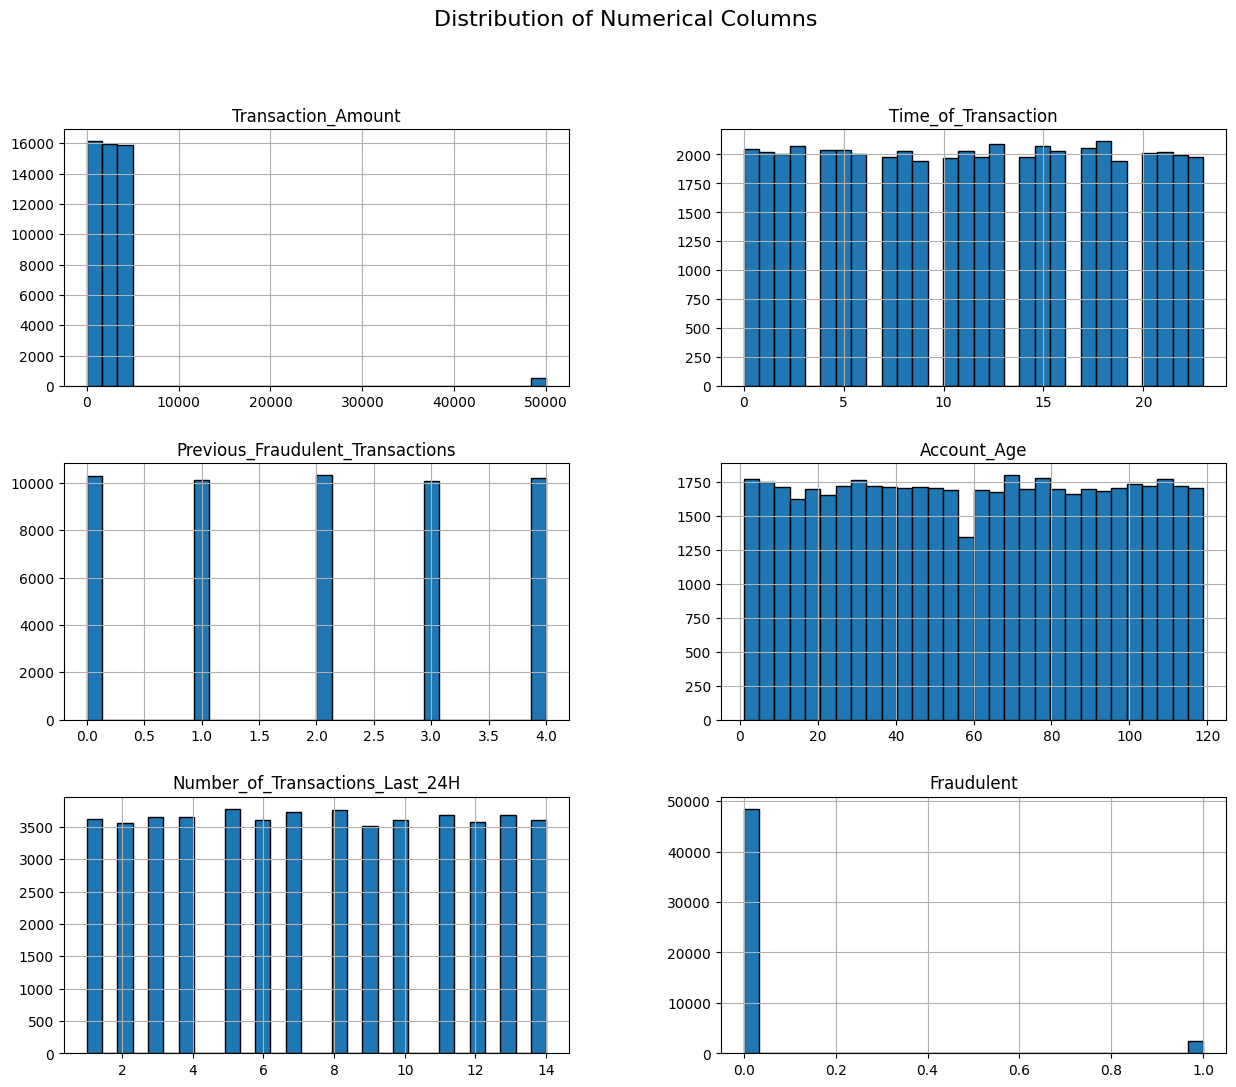

In [6]:
num_cols = fraud.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
fraud[num_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.show()

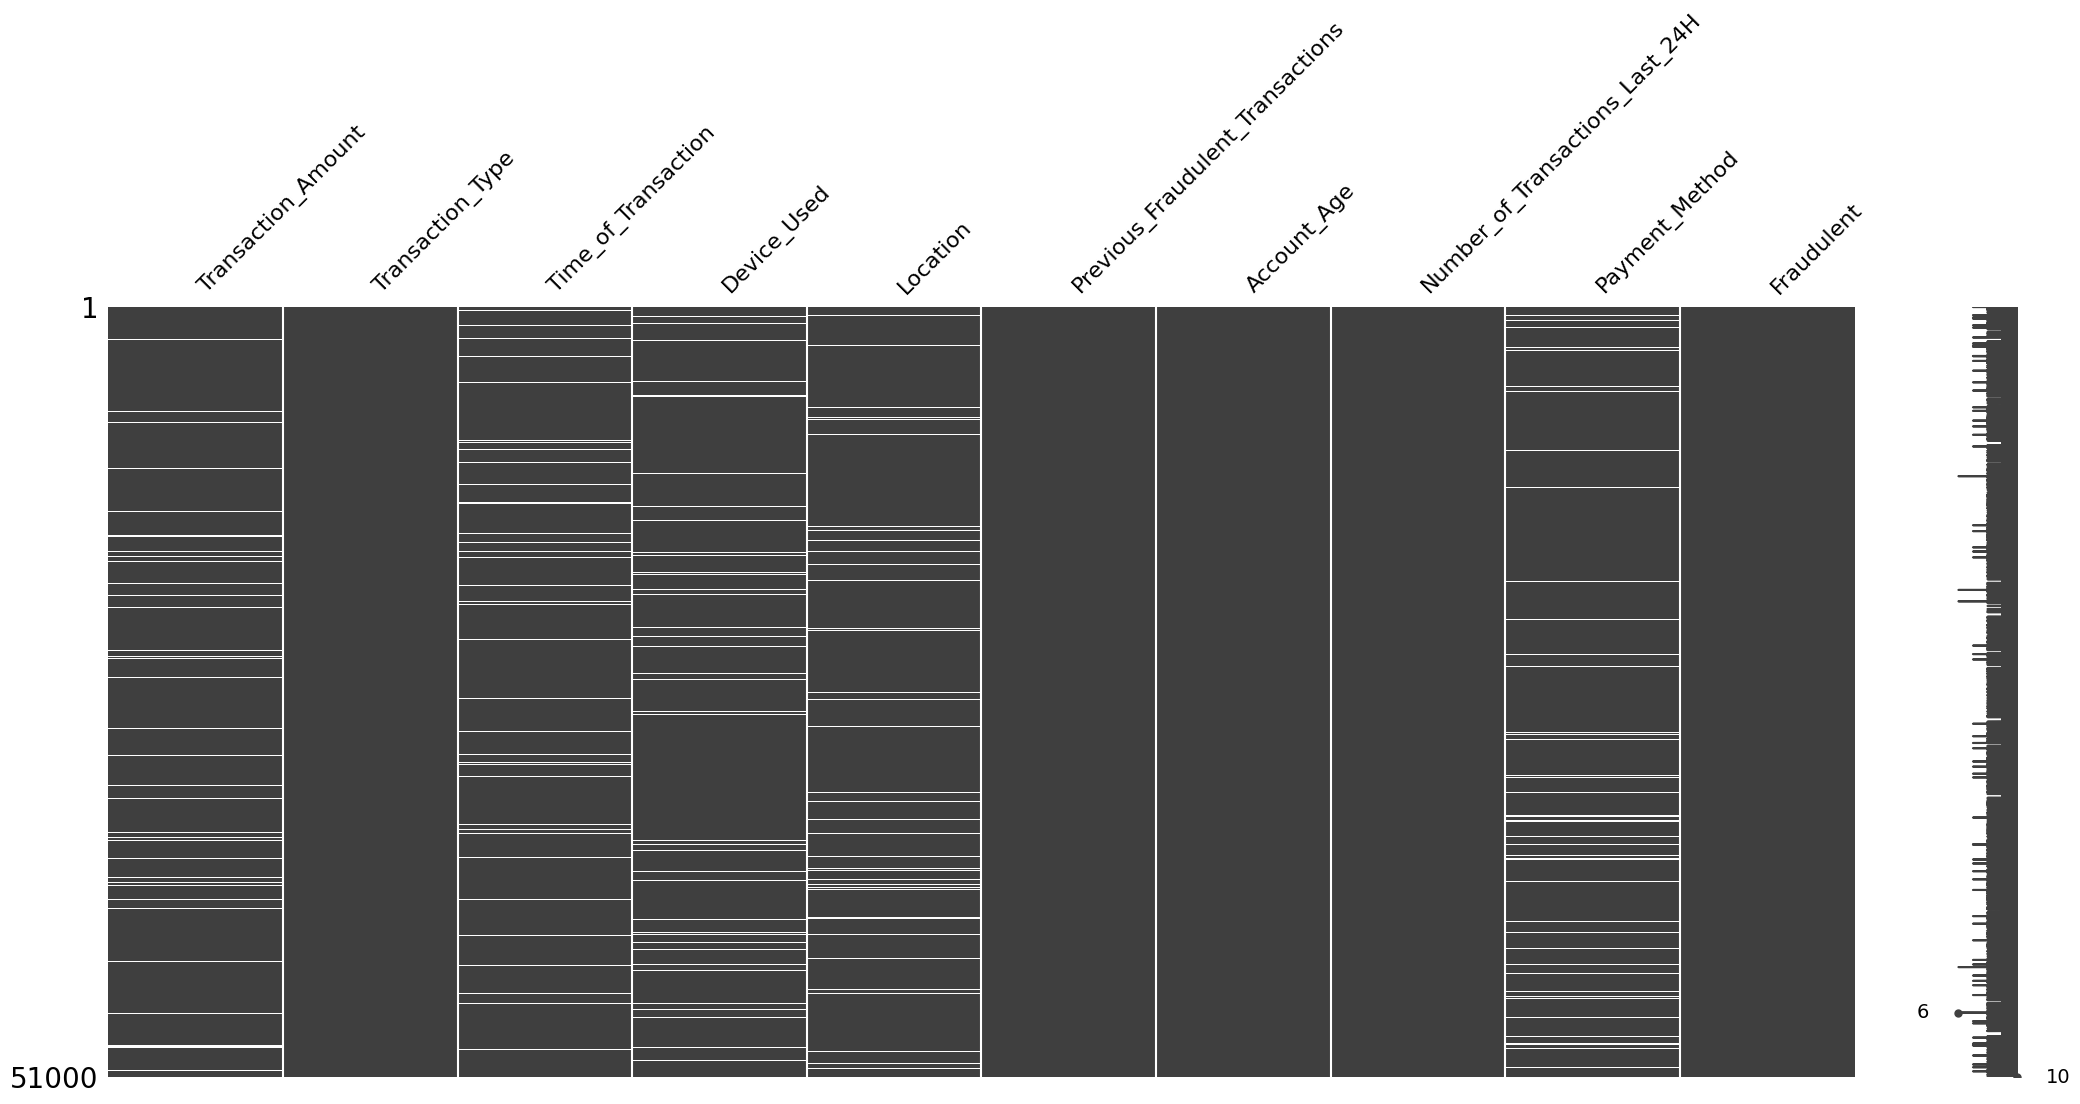

In [7]:
import missingno as msno
msno.matrix(fraud)
plt.show()

In [9]:
fraud2 = fraud.copy()

In [10]:
fraud2['Transaction_Amount'] = fraud2['Transaction_Amount'].fillna(fraud2['Transaction_Amount'].mean())
fraud2['Time_of_Transaction'] = fraud2['Time_of_Transaction'].fillna(fraud2['Time_of_Transaction'].mean())

fraud2['Device_Used'] = fraud2['Device_Used'].fillna(fraud2['Device_Used'].mode()[0])
fraud2['Location'] = fraud2['Location'].fillna(fraud2['Location'].mode()[0])
fraud2['Payment_Method'] = fraud2['Payment_Method'].fillna(fraud2['Payment_Method'].mode()[0])

In [11]:
fraud2.isnull().sum()

Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [1]:
plt.boxplot(df2['Transaction_Amount'], vert=False)
plt.show()

NameError: name 'plt' is not defined

Encode categorical columns


In [13]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Transaction_Type',
    'Device_Used',
    'Location',
    'Payment_Method'
]

le = LabelEncoder()

for col in categorical_cols:
    fraud2[col] = le.fit_transform(fraud2[col])

Define Features and Target

In [14]:
X = fraud2.drop(['Fraudulent'], axis=1)
y = fraud2['Fraudulent']

Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle Class Imbalance

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

Train Multiple Models

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Logistic Regression

In [19]:
lr = LogisticRegression()
lr.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

XGBoost

In [21]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

### Evaluate the Models

In [22]:
# Make Predictions

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

- Metric:	Why Important
- Recall:	Detects actual fraud cases
- Precision:	Reduces false alarms
- F1-score:	Balance of recall + precision
- ROC-AUC:	Overall classification quality

Classification Report

In [23]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.52      0.67      9698
           1       0.05      0.48      0.09       502

    accuracy                           0.52     10200
   macro avg       0.50      0.50      0.38     10200
weighted avg       0.91      0.52      0.64     10200

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       0.76      0.03      0.05       502

    accuracy                           0.95     10200
   macro avg       0.86      0.51      0.51     10200
weighted avg       0.94      0.95      0.93     10200

XGBoost
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.9

dataset is highly imbalanced:

- Class 0 = non-fraud → 9,698 samples
- Class 1 = fraud → 502 samples

Logistic Regression
- Recall - The model detected about 48% of total fraud
- Precision - many legitimate transactions flagged as fraud - false positive
- To mnay FP

Random Forest
- Fails fraud detection

XGBoost
- caught zero fraud cases


In [ ]:
# Evaluate using better metrics
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[9694    4]
 [ 489   13]]


In [25]:
# F1 Score
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred_rf)

print(f1)

0.05009633911368015


In [26]:
# ROC-AUC Score

from sklearn.metrics import roc_auc_score

probs = rf.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, probs)

print(auc)

0.5145080638469015


Comparison table

In [27]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

import pandas as pd

# Store models in a dictionary
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

# Create empty list
results = []

# Loop through models
for name, model in models.items():
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Append results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

# Create comparison table
comparison_df = pd.DataFrame(results)

# Sort by Recall or F1 Score
comparison_df = comparison_df.sort_values(
    by='Recall',
    ascending=False
)

# Display table
print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.516863   0.049287  0.482072  0.089431  0.489442
1        Random Forest  0.951667   0.764706  0.025896  0.050096  0.514508
2              XGBoost  0.950784   0.000000  0.000000  0.000000  0.506044


In [28]:
print(fraud2['Fraudulent'].value_counts())

Fraudulent
0    48490
1     2510
Name: count, dtype: int64


fix data a bit - SMOTE

In [29]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [30]:
#train models
model.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Use Class Weights

In [31]:
lr = LogisticRegression(class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]), eval_metric='logloss')

In [32]:
#train

lr.fit(X_train_smote, y_train_smote)
rf.fit(X_train_smote, y_train_smote)
xgb.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [35]:
lr.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [36]:
#make prediction
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

In [37]:
#Evaluate the Models Again
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.52      0.67      9698
           1       0.05      0.48      0.09       502

    accuracy                           0.52     10200
   macro avg       0.50      0.50      0.38     10200
weighted avg       0.91      0.52      0.64     10200

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       0.76      0.03      0.05       502

    accuracy                           0.95     10200
   macro avg       0.86      0.51      0.51     10200
weighted avg       0.94      0.95      0.93     10200

XGBoost
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      9698
           1       0.05      0.29      0.08       502

    accuracy                           0.68     10200
   macro avg       0.50      0.49      0.44     10200
weighted avg       0.91      0.6

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []
for name, model in models.items():
    
    y_pred = model.predict(X_test_scaled)
    
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.516863   0.049287  0.482072  0.089431  0.489442
1        Random Forest  0.951667   0.764706  0.025896  0.050096  0.514508
2              XGBoost  0.682647   0.047635  0.286853  0.081702  0.499135


In [39]:
y_probs = rf.predict_proba(X_test_scaled)[:,1]

y_pred_custom = (y_probs > 0.3).astype(int)

In [40]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9698
           1       0.15      0.04      0.06       502

    accuracy                           0.94     10200
   macro avg       0.55      0.51      0.52     10200
weighted avg       0.91      0.94      0.93     10200



### Make adjustments

In [41]:
#One-Hot Encoding
fraud3 = pd.get_dummies(
    fraud2,
    columns=[
        'Transaction_Type',
        'Device_Used',
        'Location',
        'Payment_Method'
    ],
    drop_first=True
)

In [42]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    random_state=42
)

In [43]:
df = fraud3.copy()

In [ ]:
# Add Feature Engineering
df['High_Amount'] = (df['Transaction_Amount'] > 5000).astype(int)

df['Night_Transaction'] = (
    (df['Time_of_Transaction'] >= 0) &
    (df['Time_of_Transaction'] <= 5)
).astype(int)

df['New_Account'] = (
    df['Account_Age'] < 30
).astype(int)


In [55]:
X = df.drop(['Fraudulent'], axis=1)
y = df['Fraudulent']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [61]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [62]:
# Predict Probabilities

y_probs = xgb.predict_proba(X_test_scaled)[:,1]

In [ ]:
y_pred_custom = (y_probs > 0.3).astype(int)

In [64]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.44      0.60      9698
           1       0.05      0.58      0.09       502

    accuracy                           0.44     10200
   macro avg       0.50      0.51      0.35     10200
weighted avg       0.91      0.44      0.57     10200



In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1:", f1_score(y_test, y_pred_custom))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

Accuracy: 0.44382352941176473
Precision: 0.050269612106453296
Recall: 0.5756972111553785
F1: 0.09246520556710926
ROC-AUC: 0.5051682320008479


In [66]:
fraud3.describe()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,4917.736637,6.747518,1.415150,34.384131,4.020080,0.216320
min,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,1333.787500,6.000000,1.000000,30.000000,4.000000,0.000000
50%,2656.165000,11.488400,2.000000,60.000000,7.000000,0.000000
75%,3724.987500,17.000000,3.000000,90.000000,11.000000,0.000000
max,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [67]:
fraud3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                51000 non-null  float64
 1   Time_of_Transaction               51000 non-null  float64
 2   Previous_Fraudulent_Transactions  51000 non-null  int64  
 3   Account_Age                       51000 non-null  int64  
 4   Number_of_Transactions_Last_24H   51000 non-null  int64  
 5   Fraudulent                        51000 non-null  int64  
 6   Transaction_Type_1                51000 non-null  bool   
 7   Transaction_Type_2                51000 non-null  bool   
 8   Transaction_Type_3                51000 non-null  bool   
 9   Transaction_Type_4                51000 non-null  bool   
 10  Device_Used_1                     51000 non-null  bool   
 11  Device_Used_2                     51000 non-null  bool   
 12  Devi

In [68]:
fraud3.head()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_1,Transaction_Type_2,Transaction_Type_3,Transaction_Type_4,...,Location_2,Location_3,Location_4,Location_5,Location_6,Location_7,Payment_Method_1,Payment_Method_2,Payment_Method_3,Payment_Method_4
0,1292.76,16.0000,0,119,13,0,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1,1554.58,13.0000,4,79,3,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2395.02,11.4884,3,115,9,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,100.10,15.0000,4,3,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1490.50,19.0000,2,57,7,0,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
# Check feature importance: They all look okay after review

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                             Feature  Importance
2   Previous_Fraudulent_Transactions    0.174992
4    Number_of_Transactions_Last_24H    0.080870
9                      Device_Used_1    0.061922
10                     Device_Used_2    0.057461
25                       New_Account    0.055733
24                 Night_Transaction    0.051603
22                  Payment_Method_4    0.042267
19                  Payment_Method_1    0.036970
1                Time_of_Transaction    0.036704
21                  Payment_Method_3    0.033652
7                 Transaction_Type_3    0.030239
5                 Transaction_Type_1    0.029708
6                 Transaction_Type_2    0.027703
8                 Transaction_Type_4    0.027291
12                        Location_1    0.023685
11                     Device_Used_3    0.023149
15                        Location_4    0.023066
18                        Location_7    0.023054
13                        Location_2    0.022422
17                  

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.05)

results = []

y_probs = xgb.predict_proba(X_test_scaled)[:,1]

for threshold in thresholds:
    
    y_pred = (y_probs > threshold).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

results_df = pd.DataFrame(results)

print(results_df)

    Threshold  Precision    Recall        F1
0        0.10   0.048852  0.898406  0.092665
1        0.15   0.049025  0.826693  0.092562
2        0.20   0.049215  0.743028  0.092315
3        0.25   0.049011  0.651394  0.091163
4        0.30   0.050270  0.575697  0.092465
5        0.35   0.050764  0.490040  0.091997
6        0.40   0.048843  0.378486  0.086521
7        0.45   0.049768  0.298805  0.085324
8        0.50   0.050886  0.223108  0.082871
9        0.55   0.053156  0.159363  0.079721
10       0.60   0.065076  0.119522  0.084270
11       0.65   0.079922  0.081673  0.080788
12       0.70   0.094828  0.043825  0.059946
13       0.75   0.126437  0.021912  0.037351
14       0.80   0.227273  0.009960  0.019084
15       0.85   0.000000  0.000000  0.000000
16       0.90   0.000000  0.000000  0.000000
17       0.95   0.000000  0.000000  0.000000


Use best threshold now

In [78]:
best_threshold = 0.20

y_pred_final = (y_probs > best_threshold).astype(int)

Evaluate Features

In [74]:
df['HighAmount_Night'] = (
    (df['High_Amount'] == 1) &
    (df['Night_Transaction'] == 1)
).astype(int)

In [75]:
df['NewAccount_HighFreq'] = (
    (df['New_Account'] == 1) &
    (df['Number_of_Transactions_Last_24H'] > 20)
).astype(int)

In [76]:
df['PreviousFraud_HighAmount'] = (
    (df['Previous_Fraudulent_Transactions'] > 0) &
    (df['High_Amount'] == 1)
).astype(int)

In [77]:
corr = df.corr(numeric_only=True)

print(corr['Fraudulent'].sort_values(ascending=False))

Fraudulent                          1.000000
Location_1                          0.009856
Device_Used_1                       0.007384
PreviousFraud_HighAmount            0.007100
Time_of_Transaction                 0.006845
High_Amount                         0.006388
Account_Age                         0.006203
Transaction_Type_3                  0.006192
HighAmount_Night                    0.005812
Transaction_Amount                  0.005368
Location_3                          0.003968
Payment_Method_4                    0.002108
Transaction_Type_4                  0.001964
Previous_Fraudulent_Transactions    0.001136
Location_4                          0.000886
Transaction_Type_2                  0.000701
Location_6                          0.000688
Payment_Method_3                   -0.000032
Device_Used_3                      -0.000159
Payment_Method_2                   -0.001222
Payment_Method_1                   -0.001901
Transaction_Type_1                 -0.002653
Location_5

In [81]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.26      0.40      9698
           1       0.05      0.74      0.09       502

    accuracy                           0.28     10200
   macro avg       0.50      0.50      0.25     10200
weighted avg       0.91      0.28      0.39     10200



In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

Accuracy: 0.28088235294117647
Precision: 0.04921493600738884
Recall: 0.7430278884462151
F1: 0.0923153075114466
ROC-AUC: 0.5051682320008479


Hyper Tuning

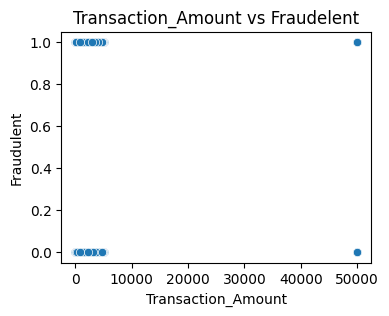

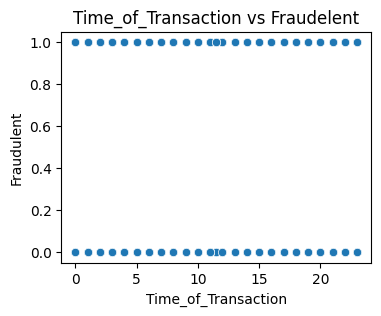

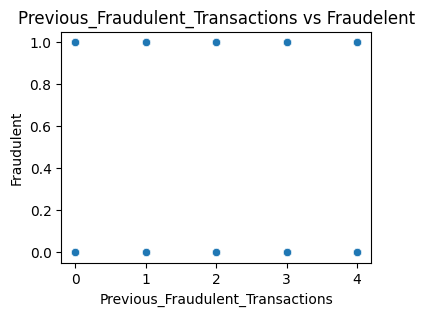

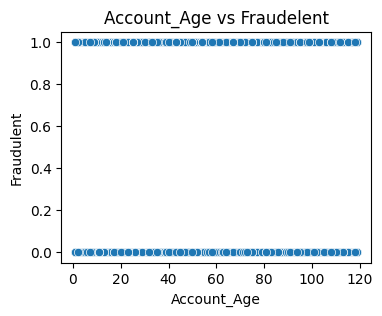

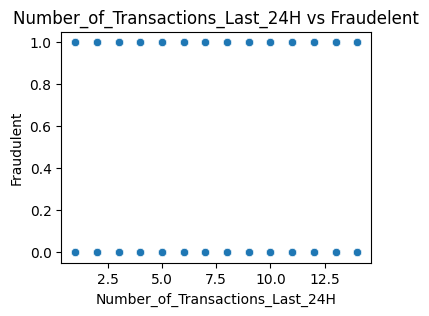

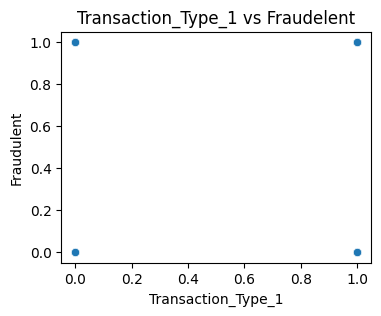

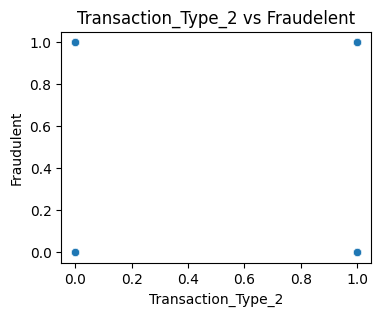

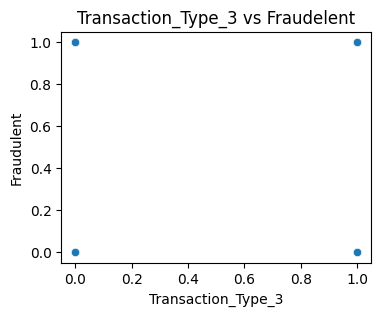

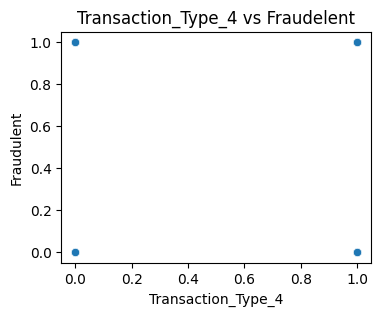

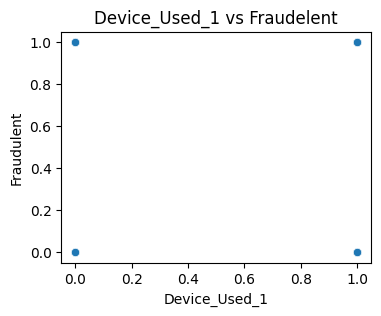

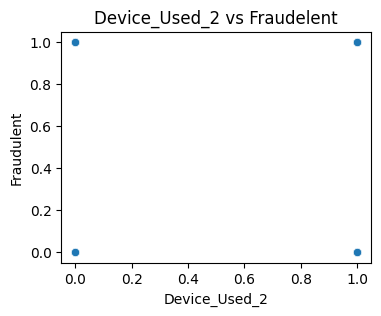

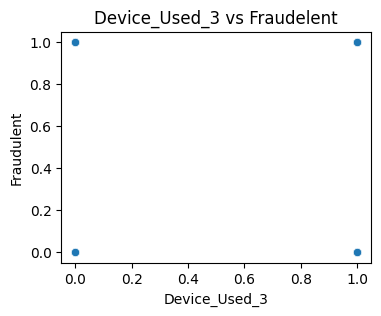

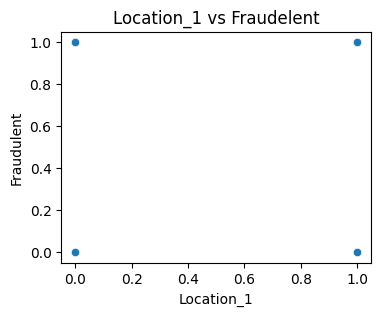

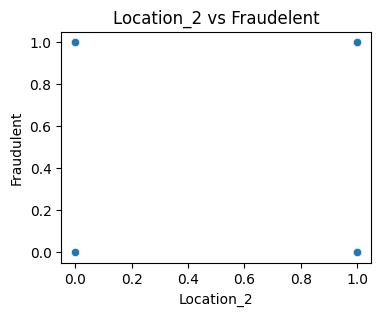

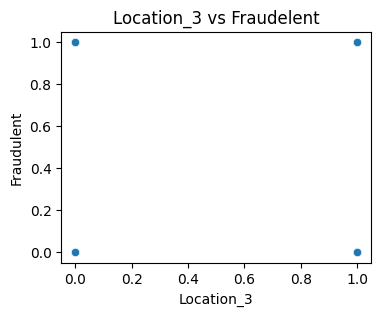

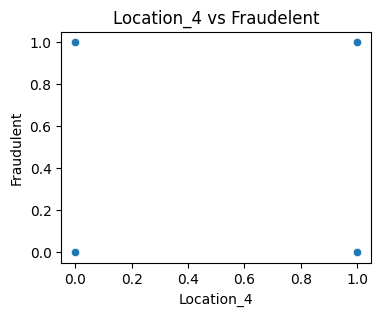

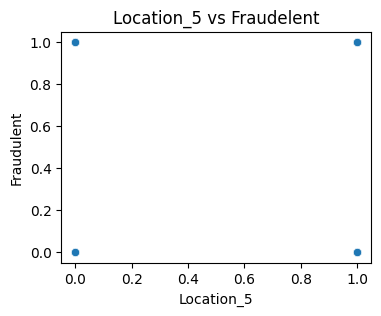

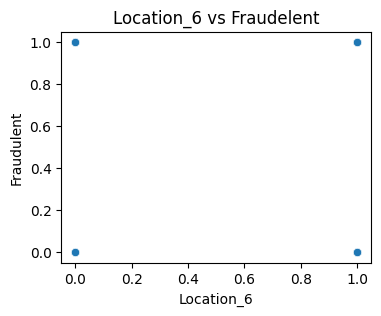

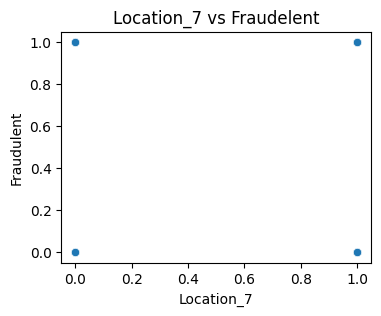

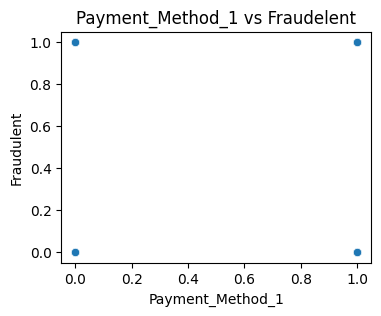

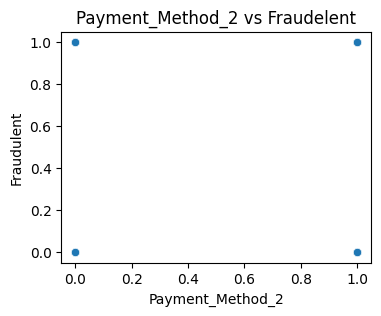

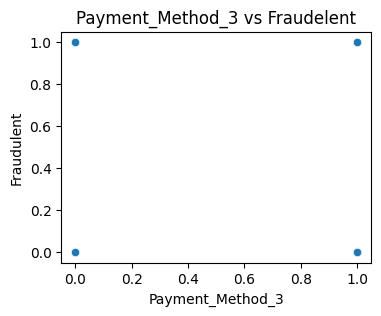

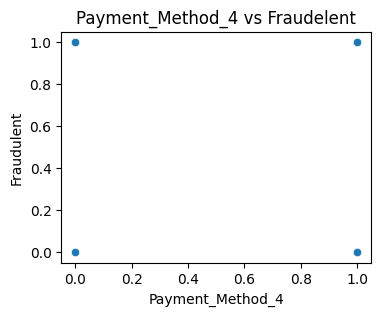

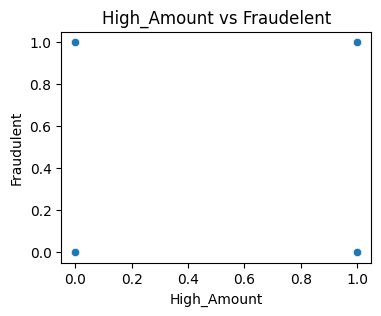

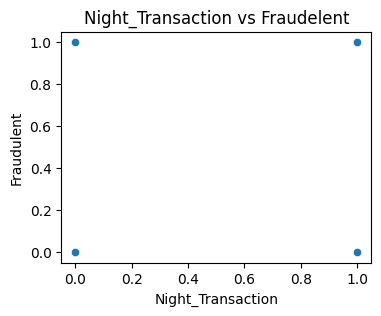

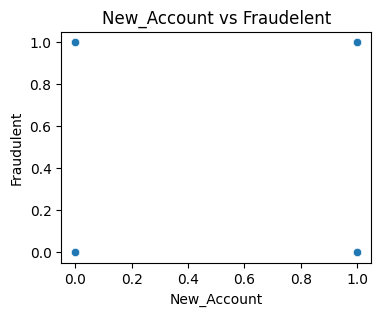

In [84]:
for col in X.columns:
    plt.figure(figsize=(4,3))
    sns.scatterplot(x=X[col], y=y)
    plt.title(f"{col} vs Fraudelent")
    plt.show()

In [86]:
fraud3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                51000 non-null  float64
 1   Time_of_Transaction               51000 non-null  float64
 2   Previous_Fraudulent_Transactions  51000 non-null  int64  
 3   Account_Age                       51000 non-null  int64  
 4   Number_of_Transactions_Last_24H   51000 non-null  int64  
 5   Fraudulent                        51000 non-null  int64  
 6   Transaction_Type_1                51000 non-null  bool   
 7   Transaction_Type_2                51000 non-null  bool   
 8   Transaction_Type_3                51000 non-null  bool   
 9   Transaction_Type_4                51000 non-null  bool   
 10  Device_Used_1                     51000 non-null  bool   
 11  Device_Used_2                     51000 non-null  bool   
 12  Devi

In [88]:
#split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [89]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score

lr_model = LinearRegression()

scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Linear Regression R² scores:", scores)
print("Mean R²:", scores.mean())

Linear Regression R² scores: [-0.00058063 -0.00122766 -0.00031354 -0.00108836 -0.00072697]
Mean R²: -0.0007874311351627305


In [90]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

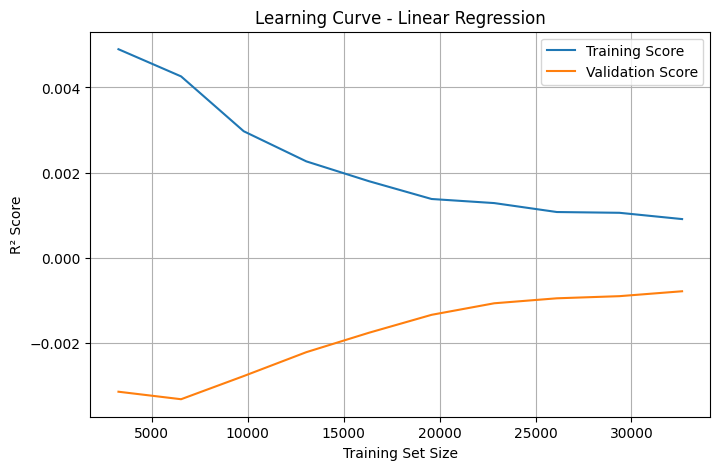

In [91]:
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()